**Random Forest Classifier**

In [65]:
# import necessary libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier # ensemble: A module that contains ensemble learning algorithms.
# RandomForestClassifier is a supervised machine learning algorithm used for classification problems.
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.datasets import load_diabetes

In [66]:
# load the data
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
# data.data contains the input features(X) of the dataset
# data.feature_names contains the names of all input features
df['diabetes'] = data.target
# data.target contains the target values (outputs of the dataset)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,diabetes
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       442 non-null    float64
 1   sex       442 non-null    float64
 2   bmi       442 non-null    float64
 3   bp        442 non-null    float64
 4   s1        442 non-null    float64
 5   s2        442 non-null    float64
 6   s3        442 non-null    float64
 7   s4        442 non-null    float64
 8   s5        442 non-null    float64
 9   s6        442 non-null    float64
 10  diabetes  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


<Axes: xlabel='age', ylabel='diabetes'>

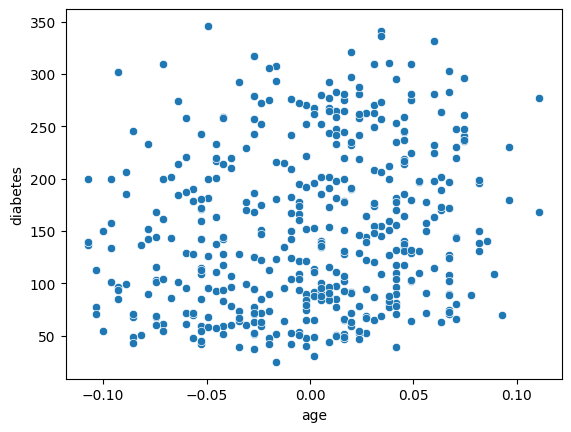

In [68]:
# visualising age and diabetes
import seaborn as sns
sns.scatterplot(x='age', y='diabetes', data=df) # scatterplot is used to show relationship between two numerical columns

In [69]:
# feature engineering
df['diabetes'] = [1 if i >= 125 else 0 for i in df['diabetes']]
df['diabetes'].unique() # converting a continuous target variable to a binary target variable (0 or 1).

array([1, 0])

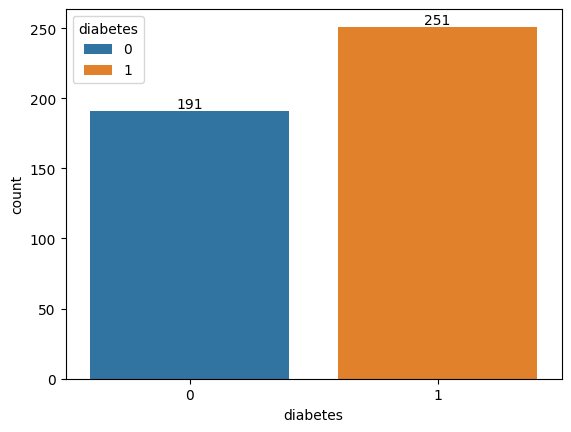

In [70]:
# visualize count of diabetes
a = sns.countplot(x='diabetes', data=df, hue='diabetes') # hue: variable used to assign different colours
for i in a.containers: # loops through each group of bars       # collection of bar groups (BarContainer objects)
  a.bar_label(i) # adds labels to each bar

In [71]:
# divide the data
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

# split the data into training and testing sets
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
# training the model
model = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=42)
# max_depth : max height of the tree
# n_estimators : how many decision trees must be made in the (ensemble) random forest
model.fit(Xtrain, ytrain)

RandomForestClassifier(max_depth=2, random_state=42)

In [73]:
# find training and testing efficiency
print(f'Training Efficiency: {round(model.score(Xtrain, ytrain) * 100, 2)}')
print(f'Testing Efficiency: {round(model.score(Xtest, ytest) * 100, 2)}')

Training Efficiency: 77.9
Testing Efficiency: 69.66


In [74]:
ypred = model.predict(Xtest)
confusion_matrix(ytest, ypred)

array([[25, 18],
       [ 9, 37]])

In [75]:
print(f"Accuracy: {round(accuracy_score(ytest, ypred) * 100, 2)}")
print(f"Precision: {round(precision_score(ytest, ypred) * 100, 2)}")
print(f"Recall: {round(recall_score(ytest, ypred) * 100, 2)}")
print(f"F1 Score: {round(f1_score(ytest, ypred) * 100, 2)}")

Accuracy: 69.66
Precision: 67.27
Recall: 80.43
F1 Score: 73.27


**Random Forest Regressor**

In [76]:
# importing libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
# RandomForestRegressor is a supervised ML algorithm used for regression problems.
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
# from sklearn.datasets import fetch_california_housing

In [78]:
# load data
# data = fetch_california_housing()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df[data.target_names[0]] = data.target
# df.head()

df = pd.read_excel("fetch_california_housing.xlsx")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


In [79]:
# divide the data
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

# split the data into training and testing sets
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
# training the model
model = RandomForestRegressor(n_estimators=35, max_depth=7, random_state=42)
# max_depth : max height of the tree
# n_estimators : how many decision trees must be made in the (ensemble) random forest
model.fit(Xtrain, ytrain)

RandomForestRegressor(max_depth=7, n_estimators=35, random_state=42)

In [81]:
# find training and testing efficiency
print(f'Training Efficiency: {round(model.score(Xtrain, ytrain) * 100, 2)}')
print(f'Testing Efficiency: {round(model.score(Xtest, ytest) * 100, 2)}')

Training Efficiency: 76.46
Testing Efficiency: 71.08


In [82]:
ypred = model.predict(Xtest)

In [83]:
print(f"r2: {round(r2_score(ytest, ypred) * 100, 2)}")
print(f"MAE: {round(mean_absolute_error(ytest, ypred) * 100, 2)}")

r2: 71.08
MAE: 43.15
